# Monte Carlo Portfolio Risk Analysis 2.0

This notebook simulates a correlated three-asset portfolio and evaluates downside and tail risk using VaR, CVaR, stress scenarios, correlation validation, and convergence analysis.

**Important:** the portfolio inputs are illustrative assumptions, not calibrated market forecasts.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allow imports when the notebook is opened from the notebooks folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_model import (
    PortfolioConfig,
    annual_covariance,
    portfolio_annual_statistics,
    simulate_portfolio_paths,
    risk_summary,
    empirical_asset_correlation,
    run_scenario_table,
    convergence_table,
)

pd.options.display.float_format = "{:,.4f}".format

## 1. Baseline assumptions

The model uses annual expected returns and volatilities, then simulates daily returns over 252 trading days.

In [2]:
asset_names = ["Asset A", "Asset B", "Asset C"]

base_config = PortfolioConfig(
    initial_value=1_000_000,
    weights=np.array([0.40, 0.40, 0.20]),
    annual_returns=np.array([0.08, 0.05, 0.06]),
    annual_volatilities=np.array([0.20, 0.15, 0.25]),
    correlation_matrix=np.array([
        [1.00, 0.60, 0.30],
        [0.60, 1.00, 0.50],
        [0.30, 0.50, 1.00],
    ]),
    trading_days=252,
    simulations=10_000,
    seed=42,
)

base_config.validate()

assumptions = pd.DataFrame({
    "Weight": base_config.weights,
    "Annual Expected Return": base_config.annual_returns,
    "Annual Volatility": base_config.annual_volatilities,
}, index=asset_names)

assumptions

,Weight,Annual Expected Return,Annual Volatility
Asset A,0.4000,0.0800,0.2000
Asset B,0.4000,0.0500,0.1500
Asset C,0.2000,0.0600,0.2500


## 2. Correlation, covariance, and analytical portfolio statistics

The covariance matrix combines each asset's volatility with pairwise correlation. The analytical portfolio volatility provides a useful reasonableness check before simulation.

In [3]:
correlation_df = pd.DataFrame(
    base_config.correlation_matrix, index=asset_names, columns=asset_names
)
covariance_df = pd.DataFrame(
    annual_covariance(base_config), index=asset_names, columns=asset_names
)
portfolio_return, portfolio_volatility = portfolio_annual_statistics(base_config)

print(f"Analytical expected annual portfolio return: {portfolio_return:.2%}")
print(f"Analytical annual portfolio volatility:      {portfolio_volatility:.2%}")
display(correlation_df)
display(covariance_df)

Analytical expected annual portfolio return: 6.40%
Analytical annual portfolio volatility:      15.38%


,Asset A,Asset B,Asset C
Asset A,1.0000,0.6000,0.3000
Asset B,0.6000,1.0000,0.5000
Asset C,0.3000,0.5000,1.0000


,Asset A,Asset B,Asset C
Asset A,0.0400,0.0180,0.0150
Asset B,0.0180,0.0225,0.0187
Asset C,0.0150,0.0187,0.0625


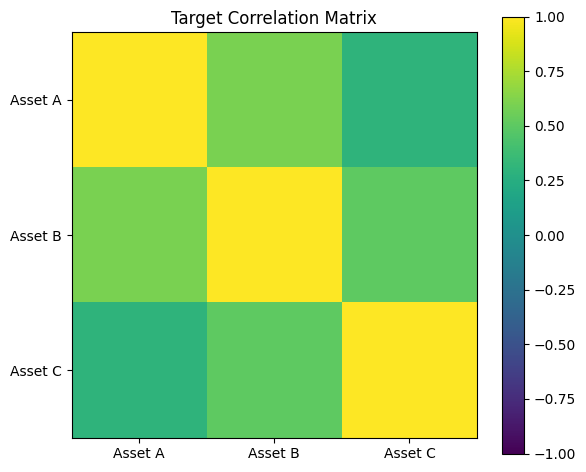

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(base_config.correlation_matrix, vmin=-1, vmax=1)
ax.set_xticks(range(len(asset_names)), asset_names)
ax.set_yticks(range(len(asset_names)), asset_names)
ax.set_title("Target Correlation Matrix")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 3. Run the 10,000-path simulation

Each row is one simulated one-year portfolio path. The model uses correlated shocks and daily geometric compounding.

In [5]:
base_result = simulate_portfolio_paths(base_config)

print("Portfolio path matrix:", base_result["paths"].shape)
print("Terminal values:", base_result["terminal_values"].shape)
print("Cholesky factor:")
display(pd.DataFrame(base_result["cholesky"], index=asset_names))

Portfolio path matrix: (10000, 252)
Terminal values: (10000,)
Cholesky factor:


,0,1,2
Asset A,1.0000,0.0000,0.0000
Asset B,0.6000,0.8000,0.0000
Asset C,0.3000,0.4000,0.8660


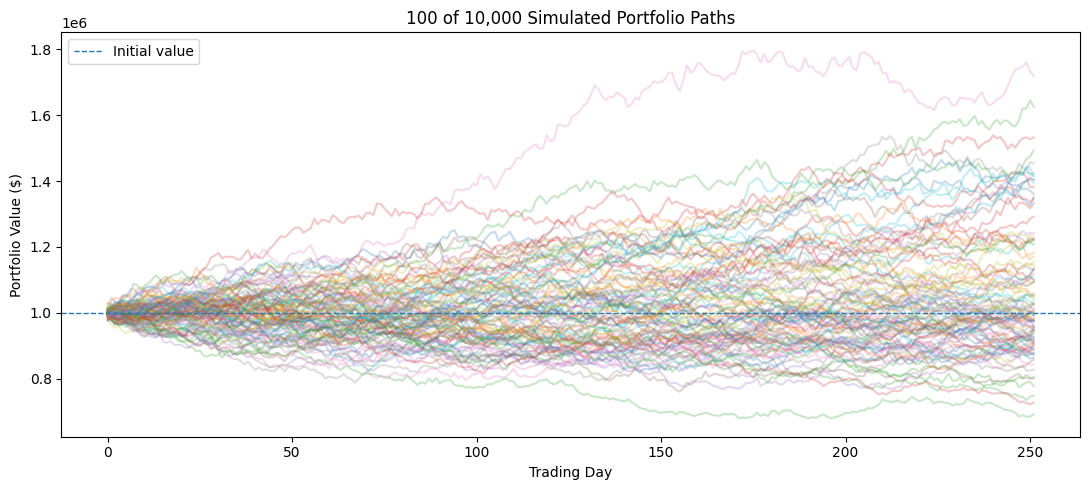

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for path in base_result["paths"][:100]:
    ax.plot(path, alpha=0.25)
ax.axhline(base_config.initial_value, linestyle="--", linewidth=1, label="Initial value")
ax.set_title("100 of 10,000 Simulated Portfolio Paths")
ax.set_xlabel("Trading Day")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Terminal distribution and loss-based VaR/CVaR

Loss is defined as:

\[
L = V_0 - V_T
\]

Positive values are losses; negative values are gains.

In [7]:
summary = risk_summary(base_result, base_config.initial_value)
summary_display = summary.copy()
money_metrics = summary_display["Metric"] != "Probability of Loss"
summary_display.loc[money_metrics, "Value"] = summary_display.loc[money_metrics, "Value"].map(
    lambda value: f"${value:,.2f}"
)
summary_display.loc[~money_metrics, "Value"] = summary_display.loc[~money_metrics, "Value"].map(
    lambda value: f"{value:.2%}"
)
summary_display

/tmp/ipykernel_518/2958276443.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['$1,000,000.00' '$1,066,892.87' '$1,056,337.10' '$163,529.00'
 '$180,240.79' '$230,227.98' '$263,563.63' '$299,882.46']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_display.loc[money_metrics, "Value"] = summary_display.loc[money_metrics, "Value"].map(


,Metric,Value
0,Initial Value,"$1,000,000.00"
1,Mean Terminal Value,"$1,066,892.87"
2,Median Terminal Value,"$1,056,337.10"
3,Terminal Value Std. Dev.,"$163,529.00"
4,Probability of Loss,36.32%
5,95% VaR,"$180,240.79"
6,95% CVaR,"$230,227.98"
7,99% VaR,"$263,563.63"
8,99% CVaR,"$299,882.46"


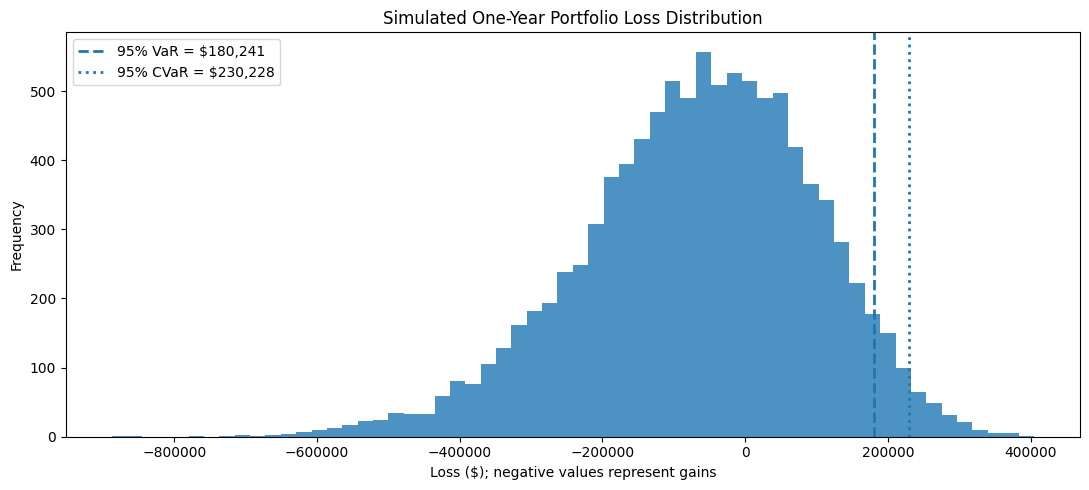

In [8]:
losses = base_result["losses"]
var_95 = float(np.quantile(losses, 0.95))
cvar_95 = float(losses[losses >= var_95].mean())

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(losses, bins=60, alpha=0.8)
ax.axvline(var_95, linestyle="--", linewidth=2, label=f"95% VaR = ${var_95:,.0f}")
ax.axvline(cvar_95, linestyle=":", linewidth=2, label=f"95% CVaR = ${cvar_95:,.0f}")
ax.set_title("Simulated One-Year Portfolio Loss Distribution")
ax.set_xlabel("Loss ($); negative values represent gains")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Validate the simulated dependence structure

The empirical correlations from all simulated asset-return observations should be close to the target matrix.

In [9]:
empirical_corr = empirical_asset_correlation(base_result["asset_log_returns"])
correlation_check = pd.DataFrame(
    empirical_corr - base_config.correlation_matrix,
    index=asset_names,
    columns=asset_names,
)
print("Empirical simulated correlation:")
display(pd.DataFrame(empirical_corr, index=asset_names, columns=asset_names))
print("Empirical minus target correlation:")
display(correlation_check)

Empirical simulated correlation:


,Asset A,Asset B,Asset C
Asset A,1.0000,0.6002,0.2996
Asset B,0.6002,1.0000,0.4994
Asset C,0.2996,0.4994,1.0000


Empirical minus target correlation:


,Asset A,Asset B,Asset C
Asset A,-0.0000,0.0002,-0.0004
Asset B,0.0002,0.0000,-0.0006
Asset C,-0.0004,-0.0006,0.0000


## 6. Stress scenarios

The scenarios isolate two important risk drivers:

- Higher correlation weakens diversification.
- Higher volatility widens the loss distribution.

In [10]:
low_corr = np.array([
    [1.00, 0.20, 0.10],
    [0.20, 1.00, 0.20],
    [0.10, 0.20, 1.00],
])
high_corr = np.array([
    [1.00, 0.90, 0.80],
    [0.90, 1.00, 0.85],
    [0.80, 0.85, 1.00],
])

scenarios = {
    "Low Correlation": {"correlation_matrix": low_corr, "seed": 42},
    "Base Case": {"seed": 42},
    "High Correlation": {"correlation_matrix": high_corr, "seed": 42},
    "High Volatility": {
        "annual_volatilities": base_config.annual_volatilities * 2,
        "seed": 42,
    },
}

scenario_results = run_scenario_table(base_config, scenarios)
scenario_results

,Mean Terminal Value,Probability of Loss,95% VaR,95% CVaR
Scenario,,,,
Low Correlation,"1,066,960.1459",0.3292,"140,050.1113","186,020.3831"
Base Case,"1,066,892.8747",0.3632,"180,240.7918","230,227.9807"
High Correlation,"1,066,423.5621",0.3938,"219,388.6812","274,245.1966"
High Volatility,"1,067,214.9871",0.4729,"384,367.3520","455,519.3839"


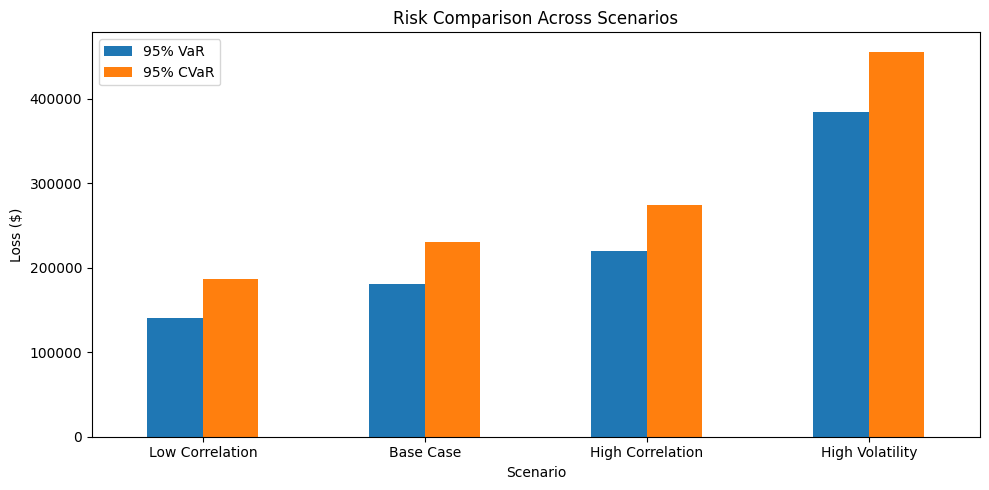

In [11]:
scenario_results[["95% VaR", "95% CVaR"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
plt.title("Risk Comparison Across Scenarios")
plt.ylabel("Loss ($)")
plt.tight_layout()
plt.show()

## 7. Monte Carlo convergence

Simulation estimates contain sampling error. This table shows how VaR and CVaR change as the number of paths grows.

In [12]:
convergence = convergence_table(base_config)
convergence

,VaR,CVaR
Simulations,,
500,"194,308.2092","232,549.1703"
1000,"185,626.1855","232,025.4663"
2500,"174,844.4258","226,181.0390"
5000,"178,391.8744","228,421.3062"
10000,"180,240.7918","230,227.9807"


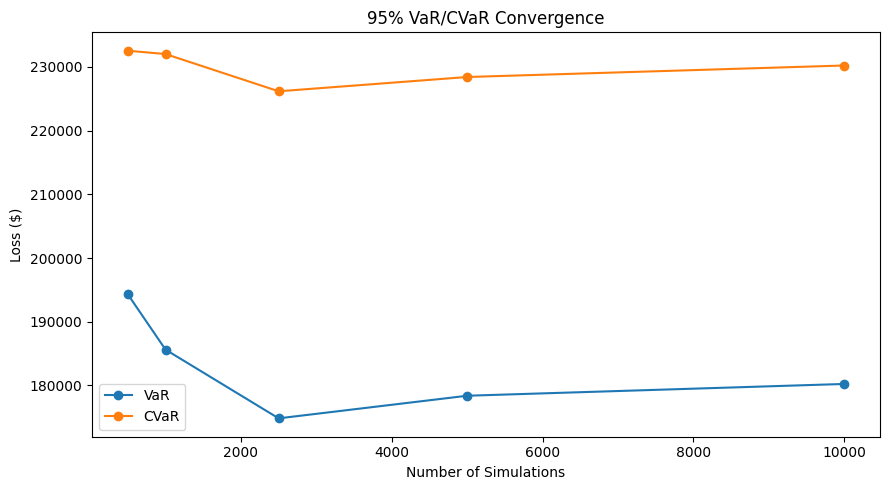

In [13]:
convergence.plot(marker="o", figsize=(9, 5))
plt.title("95% VaR/CVaR Convergence")
plt.xlabel("Number of Simulations")
plt.ylabel("Loss ($)")
plt.tight_layout()
plt.show()

## 8. Conclusions

1. The model creates a full distribution rather than one forecast.
2. VaR measures a loss cutoff; CVaR measures average severity beyond that cutoff.
3. Higher correlation reduces diversification.
4. Higher volatility increases tail risk.
5. Correlation validation and convergence checks make the simulation more defensible.
6. The largest limitation is the use of constant parameters and normally distributed innovations.

A logical next step is historical calibration, VaR backtesting, or GARCH-based volatility.